# Umbralización global, Otsu y adaptive threshold - versión simplificada

Este cuaderno compara tres formas de convertir una imagen en escala de grises en una máscara binaria:

- **Umbralización global manual**: se elige un valor fijo.
- **Otsu**: OpenCV calcula automáticamente un umbral global a partir del histograma.
- **Adaptive threshold**: el umbral se calcula por zonas locales, útil cuando la iluminación no es uniforme.

La versión fue simplificada para ejecutar más rápido: usa menos celdas, agrupa visualizaciones, evita repetir código y busca la imagen de trabajo aunque el notebook se abra desde otra carpeta.

In [1]:
# Importamos las librer?as necesarias.
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Configuraci?n visual simple para que las figuras no sean enormes ni pesadas.
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

In [ ]:
def encontrar_imagen(nombre="notes.png"):
    candidatos = [
        Path("Imagenes") / nombre,
        Path("005  - computer_vision_parte_1") / "002 - PRA" / "Imagenes" / nombre,
        Path.cwd() / "Imagenes" / nombre,
    ]

    for ruta in candidatos:
        if ruta.exists():
            return ruta

    # Si no aparece en las rutas esperadas, hacemos una búsqueda acotada dentro del proyecto.
    encontrados = list(Path.cwd().rglob(nombre))
    if encontrados:
        return encontrados[0]

    raise FileNotFoundError(f"No se encontr? {nombre}. Revis? que est? en la carpeta Imagenes.")


def cargar_gris(ruta):
    """Carga una imagen en escala de grises y corta la ejecuci?n si OpenCV no puede leerla."""
    imagen = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)
    if imagen is None:
        raise ValueError(f"OpenCV no pudo leer la imagen: {ruta}")
    return imagen


ruta_notas = encontrar_imagen("notes.png")
imagen = cargar_gris(ruta_notas)

print(f"Imagen cargada: {ruta_notas}")
print(f"Dimensiones: {imagen.shape[1]} x {imagen.shape[0]} p?xeles")
print(f"Tipo de dato: {imagen.dtype}")

Imagen cargada: Imagenes\notes.png
Dimensiones: 1024 x 134 p?xeles
Tipo de dato: uint8


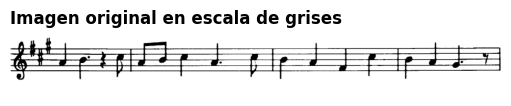

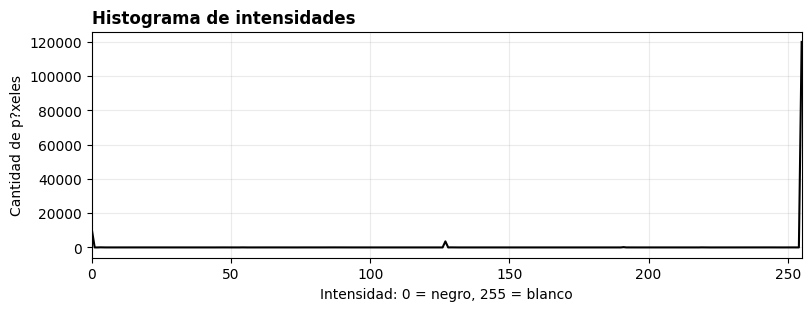

In [ ]:
# Funciones auxiliares para mostrar resultados sin repetir código.
def mostrar(imagenes, titulos, columnas=2):
    """Muestra varias imágenes en una grilla compacta."""
    filas = int(np.ceil(len(imagenes) / columnas))
    fig, ejes = plt.subplots(filas, columnas, figsize=(5 * columnas, 4 * filas), constrained_layout=True)
    ejes = np.array(ejes).reshape(-1)

    for eje, img, titulo in zip(ejes, imagenes, titulos):
        eje.imshow(img, vmin=0, vmax=255)
        eje.set_title(titulo, loc="left", fontweight="bold")
        eje.axis("off")

    for eje in ejes[len(imagenes):]:
        eje.axis("off")

    plt.show()


def mostrar_histograma(imagen_gris, titulo="Histograma de intensidades"):
    """Calcula el histograma con OpenCV, que es rápido y evita aplanar la imagen manualmente."""
    hist = cv2.calcHist([imagen_gris], [0], None, [256], [0, 256]).ravel()
    plt.figure(figsize=(8, 3), constrained_layout=True)
    plt.plot(hist, color="black")
    plt.title(titulo, loc="left", fontweight="bold")
    plt.xlabel("Intensidad: 0 = negro, 255 = blanco")
    plt.ylabel("Cantidad de p?xeles")
    plt.xlim(0, 255)
    plt.grid(alpha=0.25)
    plt.show()


def porcentaje_blanco(mascara):
    """Indica qué proporción de la máscara quedó marcada como objeto."""
    return 100 * np.count_nonzero(mascara == 255) / mascara.size


mostrar([imagen], ["Imagen original en escala de grises"], columnas=1)
mostrar_histograma(imagen)

## 1. Umbralización global manual

La umbralización global usa **un único valor de corte para toda la imagen**. En este caso usamos `THRESH_BINARY_INV` porque nos interesa que los trazos oscuros queden blancos en la máscara y el fondo claro quede negro.

Si el umbral es bajo, se detectan menos píxeles como objeto. Si el umbral es alto, se detectan más píxeles, pero también puede entrar ruido del fondo.

## 2. Umbralizacion global manual

La umbralización es una técnica de procesamiento de imágenes que convierte una imagen, normalmente en escala de grises, en una imagen más simple separando píxeles según su intensidad.
La umbralizacion global obliga a elegir un valor de corte. Todo pixel mas claro o mas oscuro que ese corte cambia de categoria. Ese mecanismo es simple y muy util para pensar el problema, pero no siempre funciona igual de bien en cualquier imagen.
Antes de ejecutar, pensalo asi: si bajas demasiado el umbral, vas a conservar demasiado fondo. Si lo subis demasiado, podes perder trazos finos.

La idea básica es elegir un valor llamado umbral. Luego se compara cada píxel con ese valor:

si intensidad del píxel >= umbral -> blanco
si intensidad del píxel < umbral  -> negro
Por ejemplo, una imagen con fondo oscuro y objetos claros, la umbralización puede ayudar a separar automáticamente los objetos del fondo.

Cómo ayuda en análisis de imágenes

Ayuda principalmente a segmentar, es decir, separar regiones importantes de la imagen. Eso sirve para tareas como:

detectar objetos;

separar texto del fondo;

contar partículas, células, monedas u otros elementos;

medir áreas;

encontrar contornos;

eliminar información irrelevante;

preparar la imagen para otros algoritmos de visión por computadora.

Por ejemplo, si querés analizar una imagen de una hoja con manchas oscuras, podés aplicar umbralización para quedarte solo con las manchas y luego medir cuánta superficie ocupan.

Hay varias formas comunes:

Umbralización global: usa un único umbral para toda la imagen.

Otsu: calcula automáticamente un umbral “óptimo” cuando hay dos grupos claros de intensidades, como objeto y fondo.

Umbralización adaptativa: calcula umbrales locales por zonas, útil cuando la iluminación no es uniforme.

En resumen: la umbralización simplifica la imagen y hace más fácil distinguir lo que te interesa del fondo.

Umbral 110: 8.63% de p?xeles marcados como objeto
Umbral 150: 11.53% de p?xeles marcados como objeto
Umbral 190: 11.84% de p?xeles marcados como objeto


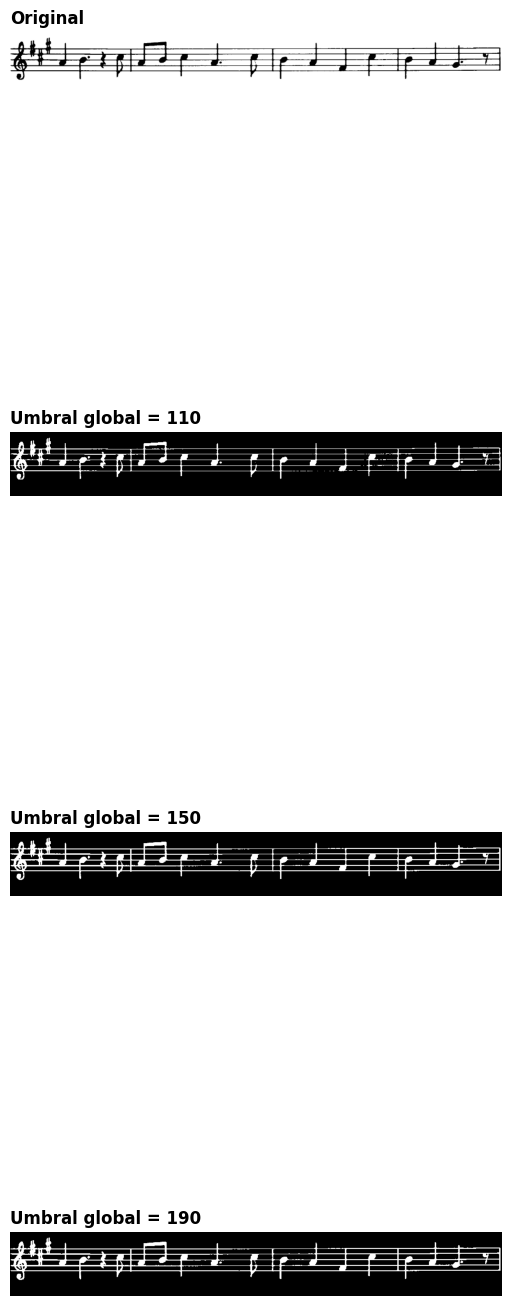

In [8]:
# Probamos varios valores de umbral sin repetir tres bloques casi iguales.
umbrales = [110, 150, 190]
mascaras_globales = []

for valor in umbrales:
    # Todo p?xel más oscuro que el umbral queda blanco por usar THRESH_BINARY_INV.
    _, mascara = cv2.threshold(imagen, valor, 255, cv2.THRESH_BINARY_INV)
    mascaras_globales.append(mascara)
    print(f"Umbral {valor}: {porcentaje_blanco(mascara):.2f}% de p?xeles marcados como objeto")

mostrar(
    [imagen] + mascaras_globales,
    ["Original"] + [f"Umbral global = {u}" for u in umbrales],
    columnas=1,
)

## 2. Otsu

`Otsu` calcula automáticamente un umbral global buscando una separación razonable entre dos grupos de intensidades. Suele funcionar bien cuando el histograma muestra una diferencia clara entre fondo y objeto.

También probamos Otsu después de un suavizado gaussiano. El suavizado puede reducir pequeñas variaciones o ruido antes de elegir el umbral.

Umbral elegido por Otsu sin suavizado: 145
Umbral elegido por Otsu con suavizado: 172
Objeto detectado con Otsu sin suavizado: 11.50%
Objeto detectado con Otsu con suavizado: 12.64%


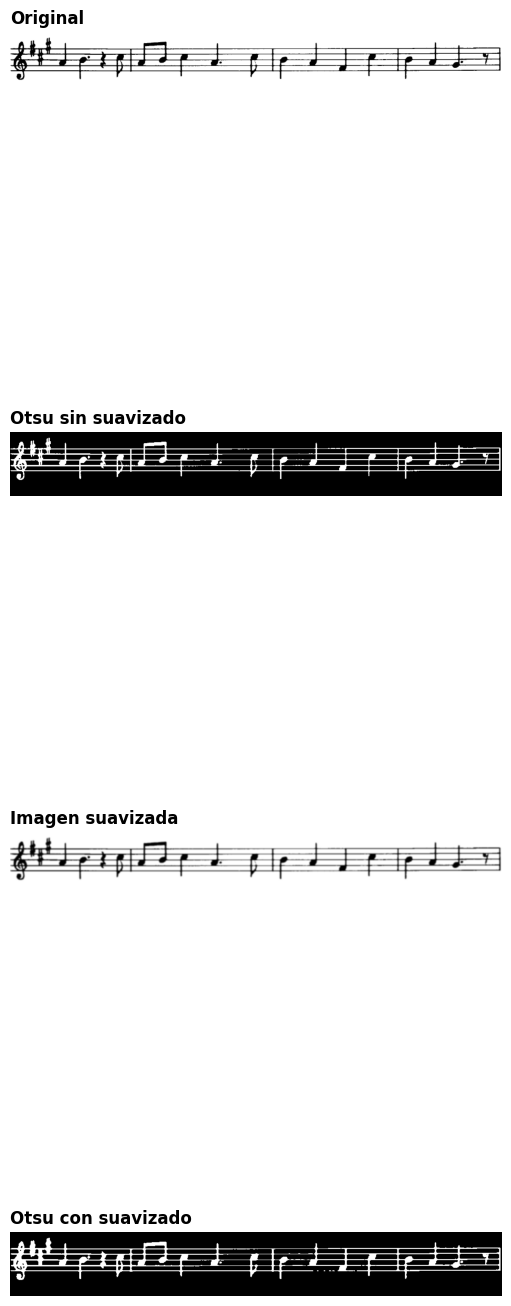

In [9]:
# Otsu sin suavizado.
umbral_otsu, mascara_otsu = cv2.threshold(
    imagen, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# Otsu con suavizado previo.
imagen_suavizada = cv2.GaussianBlur(imagen, (5, 5), 0)
umbral_otsu_suave, mascara_otsu_suave = cv2.threshold(
    imagen_suavizada, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

print(f"Umbral elegido por Otsu sin suavizado: {umbral_otsu:.0f}")
print(f"Umbral elegido por Otsu con suavizado: {umbral_otsu_suave:.0f}")
print(f"Objeto detectado con Otsu sin suavizado: {porcentaje_blanco(mascara_otsu):.2f}%")
print(f"Objeto detectado con Otsu con suavizado: {porcentaje_blanco(mascara_otsu_suave):.2f}%")

mostrar(
    [imagen, mascara_otsu, imagen_suavizada, mascara_otsu_suave],
    ["Original", "Otsu sin suavizado", "Imagen suavizada", "Otsu con suavizado"],
    columnas=1,
)

## 3. Adaptive threshold con iluminación desigual

Un umbral global puede fallar cuando una parte de la imagen está más oscura que otra. Para verlo con claridad, generamos una sombra artificial suave. Después comparamos:

- un umbral global fijo;
- Otsu, que también sigue siendo global;
- `adaptiveThreshold`, que calcula umbrales locales.

Global con sombra: 19.38% de p?xeles marcados como objeto
Otsu con sombra: 10.62% de p?xeles marcados como objeto
Adaptativa con sombra: 11.57% de p?xeles marcados como objeto


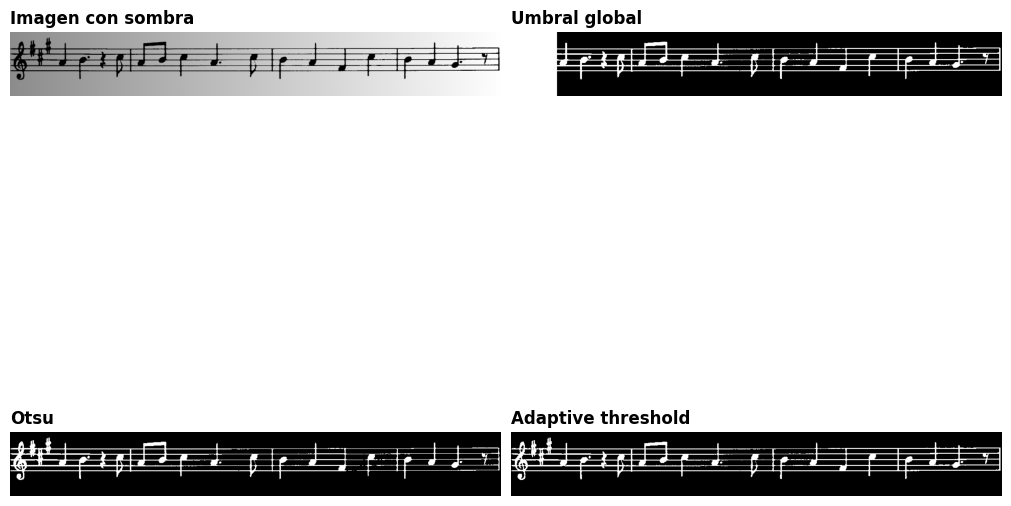

In [6]:
def agregar_sombra_gradual(imagen_gris):
    """Simula iluminaci?n desigual multiplicando la imagen por un gradiente horizontal."""
    alto, ancho = imagen_gris.shape
    gradiente = np.linspace(0.55, 1.00, ancho, dtype=np.float32)
    sombra = np.tile(gradiente, (alto, 1))
    return np.clip(imagen_gris.astype(np.float32) * sombra, 0, 255).astype(np.uint8)


imagen_sombra = agregar_sombra_gradual(imagen)

_, mascara_global_sombra = cv2.threshold(imagen_sombra, 150, 255, cv2.THRESH_BINARY_INV)
_, mascara_otsu_sombra = cv2.threshold(
    imagen_sombra, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
mascara_adaptativa = cv2.adaptiveThreshold(
    imagen_sombra,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,  # tama?o del vecindario local; debe ser impar
    11,  # constante que ajusta qu? tan exigente es el corte
)

for nombre, mascara in [
    ("Global con sombra", mascara_global_sombra),
    ("Otsu con sombra", mascara_otsu_sombra),
    ("Adaptativa con sombra", mascara_adaptativa),
]:
    print(f"{nombre}: {porcentaje_blanco(mascara):.2f}% de p?xeles marcados como objeto")

mostrar(
    [imagen_sombra, mascara_global_sombra, mascara_otsu_sombra, mascara_adaptativa],
    ["Imagen con sombra", "Umbral global", "Otsu", "Adaptive threshold"],
    columnas=2,
)

## 4. M?scara preparada para limpieza morfol?gica

Para dejar una m?scara ?til para el paso siguiente, conviene suavizar apenas la imagen y luego binarizar. La m?scara final todav?a puede tener puntos aislados o peque?as imperfecciones, pero ya est? en el formato correcto para aplicar operaciones morfol?gicas como apertura, cierre, erosi?n o dilataci?n.

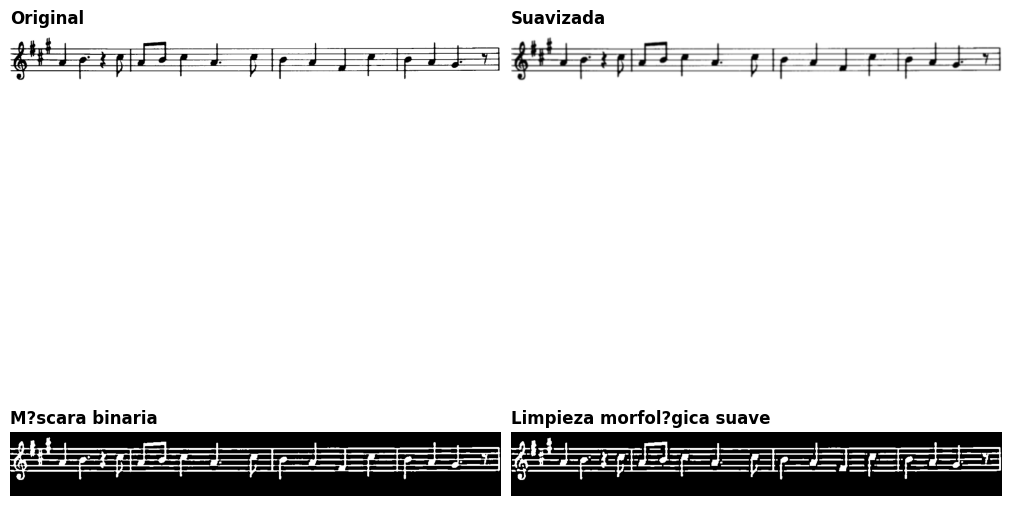

M?scara antes de limpiar: 16.28% de p?xeles blancos
M?scara despu?s de limpieza suave: 15.56% de p?xeles blancos


In [7]:
# Suavizamos antes de binarizar para reducir variaciones peque?as.
base_suavizada = cv2.GaussianBlur(imagen, (5, 5), 0)

# Generamos una m?scara binaria adaptativa, ?til si el fondo no es perfectamente parejo.
mascara_para_morfologia = cv2.adaptiveThreshold(
    base_suavizada,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    31,
    11,
)

# Ejemplo m?nimo de limpieza: apertura para quitar puntos blancos peque?os.
# Esto anticipa el cuaderno de morfolog?a sin reemplazarlo.
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
mascara_limpieza_suave = cv2.morphologyEx(mascara_para_morfologia, cv2.MORPH_OPEN, kernel)

mostrar(
    [imagen, base_suavizada, mascara_para_morfologia, mascara_limpieza_suave],
    ["Original", "Suavizada", "M?scara binaria", "Limpieza morfol?gica suave"],
    columnas=2,
)

print(f"M?scara antes de limpiar: {porcentaje_blanco(mascara_para_morfologia):.2f}% de p?xeles blancos")
print(f"M?scara despu?s de limpieza suave: {porcentaje_blanco(mascara_limpieza_suave):.2f}% de p?xeles blancos")

## Actividad breve: respuestas

**1. ?En qu? tipo de imagen elegir?as un umbral global manual?**

Elegir?a un umbral global manual cuando la imagen tiene iluminaci?n pareja, buen contraste entre objeto y fondo, y las intensidades del objeto est?n bastante separadas de las intensidades del fondo. Por ejemplo, texto oscuro sobre papel claro bien iluminado.

**2. ?Cu?ndo parece m?s razonable probar Otsu?**

Probar?a `Otsu` cuando no quiero elegir el umbral a mano y el histograma sugiere dos grupos principales: fondo por un lado y objeto por otro. Es ?til como primera opci?n autom?tica en im?genes con contraste razonable.

**3. ?Qu? problema espec?fico intenta resolver `adaptiveThreshold`?**

`adaptiveThreshold` intenta resolver el problema de la iluminaci?n no uniforme. En vez de usar un ?nico corte para toda la imagen, calcula cortes locales seg?n el vecindario de cada p?xel. Por eso puede funcionar mejor cuando hay sombras, reflejos o zonas del fondo m?s oscuras que otras.

**4. ?Por qu? conviene pensar la binarizaci?n junto con el paso siguiente de limpieza morfol?gica?**

Porque la binarizaci?n define qu? p?xeles entran en la m?scara, pero esa m?scara puede quedar con ruido, huecos o bordes irregulares. La limpieza morfol?gica permite corregir parte de esos defectos. Si el umbral se elige muy mal, la morfolog?a no puede recuperar informaci?n perdida; por eso ambos pasos deben pensarse juntos.

## Cierre

La umbralizaci?n no es solo pasar una imagen a blanco y negro. Es una decisi?n de segmentaci?n: separar la informaci?n relevante del fondo, del ruido y de los cambios de iluminaci?n. En este ejemplo, el umbral global es simple y r?pido, Otsu automatiza la elecci?n del corte y `adaptiveThreshold` resulta m?s flexible cuando el fondo no es uniforme.